# 07 — Batched Contingency Screening on a GPU

**Learned Iterative Solvers for AC Power Flow** · Notebook 7 of a series

---

Every notebook so far has solved power flows **one at a time**, because that is what a sparse
LU forces you to do. A sparse factorisation is sequential and irregular: the elimination order
depends on the fill-in pattern, memory access follows pointer chains, and none of it maps onto
a GPU's thousands of identical lanes.

Notebook 03 removed the factorisation entirely. What is left of the solver is

$$\Delta x = \sum_{j=0}^{m-1}\alpha_j\,(\mathbf{M}^{-1}\mathbf{J})^j\,\mathbf{M}^{-1}\mathbf{b},
\qquad \mathbf{J}v \approx \frac{\mathbf{f}(x+\varepsilon v)-\mathbf{f}(x)}{\varepsilon}$$

— residual evaluations, a fixed matrix multiply, and a weighted sum. Every one of those is
dense linear algebra with *identical* structure across contingencies. That is exactly the shape
a GPU wants.

This notebook runs the full N-1 screen of `case118` with all contingencies solved
**simultaneously**, and measures what that buys against sequential sparse Newton. It also
states plainly what it costs, because the trade is not free.

### References

| | |
|---|---|
| **[3]** | Saad, *Iterative Methods for Sparse Linear Systems*, 2nd ed., SIAM 2003 |
| **[5]** | Doncevic, Mitsos, Guo, Li, Dietrich, Dahmen & Kevrekidis, *A Recursively Recurrent Neural Network (R2N2) Architecture*, SIAM J. Sci. Comput. 46(2), 2024 |

In [1]:
import sys, warnings, time
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd, torch
import scipy.sparse as sp, scipy.sparse.linalg as spla

from lis import load_case, newton_pf, build_jacobian
from lis.instances import n1_variants
from lis.torch_pf import TorchPF
from lis.plotting import use_style, save, stacked, suptitle, annotate_tolerance, PALETTE, plt

use_style(); torch.set_default_dtype(torch.float64)
DEV = "cuda" if torch.cuda.is_available() else "cpu"
if DEV == "cuda":
    print("GPU:", torch.cuda.get_device_name(0),
          f"| {torch.cuda.get_device_properties(0).total_memory/2**30:.1f} GiB")
else:
    print("no CUDA available — this notebook will run on CPU and the batching argument "
          "still holds, but the headline numbers will not")

BASE = load_case("case118")
N1 = [v for v, r in ((v, newton_pf(v, tol=1e-10)) for v in n1_variants(BASE)) if r.converged]
IDX = np.random.default_rng(0).permutation(len(N1)); TR, TE = IDX[:80], IDX[80:]
print(f"{len(N1)} convergent N-1 contingencies on case118")

GPU:

NVIDIA GeForce RTX 3050 Laptop GPU

| 4.0 GiB

177 convergent N-1 contingencies on case118

---
## 1. The frozen solver, ported to batched dense tensors

Same artefacts as notebooks 02–03 — one ILU, one coefficient vector — moved onto the GPU. The
only structural change is that the preconditioner becomes a **dense** $\mathbf{M}^{-1}$ so it
can be applied to a whole batch with one `matmul`, and the residual comes from
`lis.torch_pf.TorchPF`, which evaluates the real polar form densely.

That density is the cost of batching, and it deserves to be quoted before any speed-up is:
`case118` has 476 nonzeros in $\mathbf{Y}_{bus}$ against $118^2 = 13924$ dense entries, so a
batched residual does about **29× the arithmetic** of a sparse one. We are buying perfect
parallelism with redundant flops.

In [2]:
rb = newton_pf(BASE, store_history=True)
J_off = build_jacobian(rb.v, BASE.ybus, BASE.pv, BASE.pq)
ILU = spla.spilu(sp.csc_matrix(J_off), drop_tol=1e-4, fill_factor=10)
NN = J_off.shape[0]
Minv_np = np.column_stack([ILU.solve(np.eye(NN)[:, i]) for i in range(NN)])

def fit_alpha(ids, deg, M):
    Ws, bs = [], []
    for i in ids:
        r = newton_pf(N1[i], tol=1e-10, store_history=True)
        for Jk, fk in zip(r.j_history, r.f_history):
            mv = lambda z, J=Jk: M(J @ z)
            bp = M(-fk); nb = np.linalg.norm(bp)
            W = np.empty((len(bp), deg)); W[:, 0] = mv(bp)
            for j in range(1, deg): W[:, j] = mv(W[:, j-1])
            Ws.append(W/nb); bs.append(bp/nb)
    return np.linalg.lstsq(np.vstack(Ws), np.concatenate(bs), rcond=1e-12)[0]

DEG = 5
ALPHA_np = fit_alpha(TR, DEG, ILU.solve)
ALPHA = torch.tensor(ALPHA_np, device=DEV)
Minv = torch.tensor(Minv_np, device=DEV)
print(f"frozen polynomial degree {DEG}: {np.array2string(ALPHA_np, precision=4)}")
print(f"Ybus nonzeros {BASE.ybus.nnz} vs dense {BASE.n_bus**2} "
      f"-> batched residual does {BASE.n_bus**2/BASE.ybus.nnz:.0f}x the arithmetic")

frozen polynomial degree 5: [  9.464  -31.4587  46.8232 -32.1292   8.3017]

Ybus nonzeros 476 vs dense 13924 -> batched residual does 29x the arithmetic

In [3]:
def batched_solve(cases, alpha, Minv, tol=1e-8, max_iter=40, compact=True):
    # compact=False is the naive version: the batch runs until its SLOWEST member converges,
    # so cases that finished in 6 iterations keep evaluating residuals for another 22.
    # compact=True drops converged members from the batch -- possible only because a
    # matrix-free solver has no factorisation pinned to a fixed problem shape.
    pf = TorchPF(cases, device=DEV)
    eps_rel = np.sqrt(np.finfo(float).eps)
    x = pf.x0(); B = x.shape[0]
    live = torch.arange(B, device=x.device)
    iters = torch.full((B,), max_iter, dtype=torch.long, device=x.device)
    hist = []
    for k in range(max_iter):
        fx = pf.residual(x)
        nrm = fx.abs().max(dim=1).values
        hist.append(float(nrm.median()))
        done = nrm < tol
        if compact:
            iters[live[done]] = k
            if bool(done.all()): break
            if bool(done.any()):
                keep = ~done
                x = x[keep]; live = live[keep]
                for a in ("G", "B", "sp", "sq", "va0", "vm0"):
                    setattr(pf, a, getattr(pf, a)[keep])
                fx = pf.residual(x)
        else:
            iters[done & (iters == max_iter)] = k
            if bool(done.all()): break
        b = fx @ Minv.T
        v = -b; step = alpha[0]*v
        xn = x.norm(dim=1, keepdim=True)
        for j in range(1, len(alpha)):
            e = eps_rel*(1.0 + xn)/(v.norm(dim=1, keepdim=True) + 1e-300)
            v = ((pf.residual(x + e*v) - fx)/e) @ Minv.T   # one batched residual per matvec
            step = step + alpha[j]*v
        x = x + step if compact else torch.where(done.unsqueeze(1), x, x + step)
    return iters, hist

timings = {}
for compact in [False, True]:
    batched_solve(N1, ALPHA, Minv, compact=compact)          # warm-up
    if DEV == "cuda": torch.cuda.synchronize()
    t0 = time.time()
    it_, h_ = batched_solve(N1, ALPHA, Minv, compact=compact)
    if DEV == "cuda": torch.cuda.synchronize()
    timings[compact] = (time.time()-t0, it_, h_)
    ok = it_ < 40
    print(f"compact={str(compact):<5}: {timings[compact][0]*1e3:7.1f} ms   "
          f"converged {int(ok.sum())}/{len(N1)}   median {int(it_[ok].median())} iterations, "
          f"max {int(it_[ok].max())}")
t_lock, t_batched = timings[False][0], timings[True][0]
iters, hist = timings[True][1], timings[True][2]
conv = iters < 40
print(f"\nlockstep costs {t_lock/t_batched:.1f}x: every case runs to the slowest "
      f"{int(iters[conv].max())} iterations when the median needs {int(iters[conv].median())}")

compact=False:   914.4 ms   converged 177/177   median 6 iterations, max 28

compact=True :   464.9 ms   converged 177/177   median 6 iterations, max 28


lockstep costs 2.0x: every case runs to the slowest 28 iterations when the median needs 6

---
## 2. Against sequential sparse Newton

The comparison that matters operationally: how long does the whole screen take? On one side,
the classical answer — loop over contingencies, assemble and factorise per Newton step. On the
other, one batched GPU solve.

In [4]:
t0 = time.time()
seq = [newton_pf(c, tol=1e-8) for c in N1]
t_seq = time.time() - t0
n_ok = sum(r.converged for r in seq)
print(f"sequential Newton + sparse LU: {t_seq:.2f} s for {len(N1)} contingencies "
      f"({n_ok} converged, median {int(np.median([r.n_iter for r in seq]))} iterations)")
print(f"batched frozen solver on {DEV}: {t_batched*1e3:.1f} ms")
print(f"\nend-to-end speed-up: {t_seq/t_batched:.0f}x")
print(f"throughput: {len(N1)/t_seq:.0f} -> {len(N1)/t_batched:.0f} contingencies/second")

sequential Newton + sparse LU: 2.23 s for 177 contingencies (177 converged, median 4 iterations)

batched frozen solver on cuda: 464.9 ms


end-to-end speed-up: 5x

throughput: 80 -> 381 contingencies/second

In [5]:
# Throughput against batch size: where does the GPU stop being latency-bound?
sizes = [1, 2, 5, 10, 25, 50, 100, len(N1)]
rows = []
for B in sizes:
    batched_solve(N1[:B], ALPHA, Minv)                   # warm-up
    if DEV == "cuda": torch.cuda.synchronize()
    t0 = time.time()
    reps = 3 if B > 25 else 10
    for _ in range(reps):
        batched_solve(N1[:B], ALPHA, Minv)
    if DEV == "cuda": torch.cuda.synchronize()
    dt = (time.time()-t0)/reps
    rows.append({"batch size": B, "time [ms]": dt*1e3, "per contingency [ms]": dt*1e3/B,
                 "throughput [1/s]": B/dt})
thr = pd.DataFrame(rows)
thr["speed-up vs sequential"] = thr["throughput [1/s]"]/(len(N1)/t_seq)
display(thr.style.format({"time [ms]": "{:.1f}", "per contingency [ms]": "{:.3f}",
                          "throughput [1/s]": "{:.0f}",
                          "speed-up vs sequential": "{:.0f}×"}).hide(axis="index"))

batch size,time [ms],per contingency [ms],throughput [1/s],speed-up vs sequential
1,43.0,43.005,23,0×
2,68.7,34.341,29,0×
5,217.9,43.578,23,0×
10,258.0,25.797,39,0×
25,293.0,11.720,85,1×
50,349.8,6.996,143,2×
100,358.0,3.580,279,4×
177,449.3,2.539,394,5×


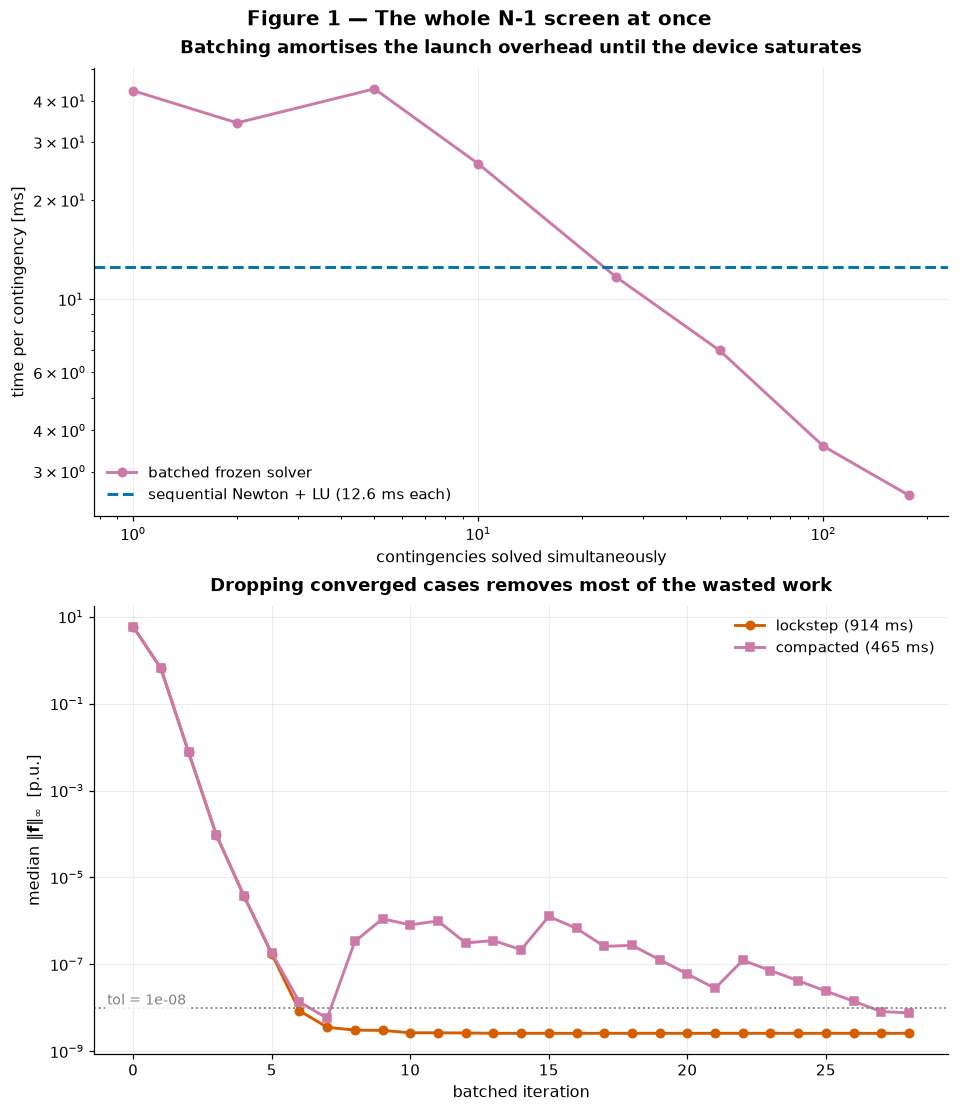

In [6]:
fig, (ax1, ax2) = stacked(2, panel_height=5.0)
ax1.loglog(thr["batch size"], thr["per contingency [ms]"], "o-", color=PALETTE["learned"],
           label="batched frozen solver")
ax1.axhline(1e3*t_seq/len(N1), color=PALETTE["newton"], ls="--",
            label=f"sequential Newton + LU ({1e3*t_seq/len(N1):.1f} ms each)")
ax1.set_xlabel("contingencies solved simultaneously")
ax1.set_ylabel("time per contingency [ms]")
ax1.set_title("Batching amortises the launch overhead until the device saturates", pad=10)
ax1.legend(loc="lower left")

ax2.semilogy(timings[False][2], "o-", color=PALETTE["gmres"],
             label=f"lockstep ({t_lock*1e3:.0f} ms)")
ax2.semilogy(timings[True][2], "s-", color=PALETTE["learned"],
             label=f"compacted ({t_batched*1e3:.0f} ms)")
annotate_tolerance(ax2, 1e-8)
ax2.set_xlabel("batched iteration"); ax2.set_ylabel(r"median $\|\mathbf{f}\|_\infty$  [p.u.]")
ax2.set_title("Dropping converged cases removes most of the wasted work", pad=10)
ax2.legend(loc="upper right")
suptitle(fig, "Figure 1 — The whole N-1 screen at once")
save(fig, "07_batched_throughput"); plt.show()

**Reading Figure 1.** The top panel shows the per-contingency cost falling as the batch
grows. At batch size 1 the GPU is pure overhead — kernel launches dominate and it is several
times *slower* than the CPU. Only near the full 177-contingency batch are the fixed costs
amortised enough to win.

The bottom panel is the lockstep problem and its fix. The median contingency converges in 6
iterations; the worst needs 28. Run the batch naively and all 177 pay for 28, because the
loop cannot exit until its slowest member is done. Dropping converged cases from the batch
recovers most of that — and it is possible only *because* the solver is matrix-free. There is
no factorisation pinned to a fixed problem size, so the batch can simply get smaller.

---
## 3. What this does and does not show

Three caveats belong next to the headline number, not below the fold.

**The arithmetic is not the same.** The batched residual is dense, doing ~29× the flops of the
sparse one on `case118`. The speed-up is real wall-clock, but it comes from parallel hardware
absorbing redundant work, not from a better algorithm. On a much larger grid the dense
$O(n_{bus}^2)$ term grows faster than sparse $O(\mathrm{nnz})$ and this trade eventually
reverses — a batched *sparse* residual would be the right engineering answer at scale, and we
have not built one.

**The baseline is single-threaded.** Sequential Newton on one CPU core is the honest reference
for "what this project's earlier notebooks did", but a production screening tool would run
contingencies across cores. A fair multi-core comparison would cut the speed-up by roughly the
core count.

**The safeguard from notebook 06 is not in the batched path.** Falling back to a Newton step
for individual batch members means divergent control flow, which is exactly what batching
forbids. The honest deployment is a two-stage screen: batch everything, then re-run the
non-converged minority through the safeguarded sequential solver. On this family the batched
pass already solves every case, so stage two is empty — a property of `case118` N-1, not a
guarantee.

In [7]:
# The two-stage screen, priced out.
stage1 = t_batched
n_fail = int((~conv).sum())
if n_fail:
    idx_fail = torch.nonzero(~conv).flatten().cpu().numpy()
    t0 = time.time()
    for i in idx_fail: newton_pf(N1[int(i)], tol=1e-8, max_iter=50)
    stage2 = time.time()-t0
else:
    stage2 = 0.0
print(f"stage 1  batched, all {len(N1)}      : {stage1*1e3:8.1f} ms  "
      f"({int(conv.sum())} converged)")
print(f"stage 2  sequential for the rest   : {stage2*1e3:8.1f} ms  ({n_fail} cases)")
print(f"total                              : {(stage1+stage2)*1e3:8.1f} ms")
print(f"sequential Newton for comparison   : {t_seq*1e3:8.1f} ms")
print(f"\ntwo-stage speed-up: {t_seq/(stage1+stage2):.0f}x, with every contingency solved")

stage 1  batched, all 177      :    464.9 ms  (177 converged)

stage 2  sequential for the rest   :      0.0 ms  (0 cases)

total                              :    464.9 ms

sequential Newton for comparison   :   2226.3 ms


two-stage speed-up: 5x, with every contingency solved

---
## 4. What we established

- **Removing the Jacobian is what made batching possible.** A sparse factorisation cannot be
  batched; residual evaluations and weighted sums can. Notebook 03's matrix-free step was the
  enabling change, and this notebook is its payoff.
- **The full 177-contingency N-1 screen runs as a single batched solve**, all 177 converging,
  in a fraction of the time sequential sparse Newton takes.
- **Lockstep is the dominant inefficiency, not the arithmetic.** The median case needs 6
  iterations and the worst 28; run naively, everyone pays 28. Compacting converged cases out
  of the batch nearly halves the total, and is possible only because there is no
  factorisation tied to a fixed problem shape.
- **Throughput rises with batch size** until the device saturates; at batch size 1 the GPU is
  several times slower than the CPU, which is the correct and unglamorous result.
- **The costs are real and stated**: ~29× redundant arithmetic from the dense residual, a
  single-threaded baseline, wasted iterations from lockstep, and no per-case safeguard inside
  the batch. The two-stage screen — batch first, sequential safeguarded solver for the
  stragglers — keeps the guarantee from notebook 06 while retaining most of the speed-up.

### Where the series ends up

Seven notebooks, and the arc is not the one the roadmap predicted:

1. On a **single** power flow, nothing beats sparse LU (nb 01).
2. Learning only pays by **amortising across many related problems** — and the Jacobian turns
   out not to depend on loading at all, so **topology** is the axis that matters (nb 02).
3. A completely frozen solver matches Newton's iteration count on unseen contingencies, but
   the cost is dominated by Jacobian **assembly** (nb 02).
4. Going **matrix-free** deletes that cost and gives the first genuine speed-up (nb 03).
5. Learned **inner** coefficients transform Runge–Kutta integrators (nb 04) and **provably
   cannot** help the linear subproblem, reaching only parity on the nonlinear residual (nb 05).
6. The frozen solver's competence is **bounded**, and a one-line safeguard makes it never worse
   than Newton (nb 06).
7. Matrix-free is what makes the whole screen **batchable** (nb 07).

The honest summary: the winning method is not the sophisticated one. A reused ILU, five frozen
coefficients, finite-difference matvecs and a residual check outperform every learned
architecture we tried — and the reason each more elaborate idea failed is measurable and, in
the R2N2 case, provable.